# Analisis Sentimen Ulasan Google Play Store
## Dicoding Submission - Machine Learning

Notebook ini berisi:
1. **Preprocessing** data hasil scraping
2. 3 Skema Pelatihan:
- Deep Learning (BiLSTM)
- Machine Learning (LinearSVC + TF-IDF Word N-gram)
- Transformer (IndoBERT Fine-tuning)
3. **Inference** untuk prediksi sentimen

In [1]:
# Install dependencies (optional for reproducibility)
!pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import emoji
import joblib
from tqdm import tqdm
warnings.filterwarnings('ignore')

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

from datasets import Dataset as HFDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [3]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=3,
    use_safetensors=True,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 1. Memuat Dataset

In [4]:
df = pd.read_csv('dataset.csv')
print(f"Jumlah data: {len(df)}")
print(f"Kolom: {df.columns.tolist()}")
df.head(10)

Jumlah data: 19056
Kolom: ['app_name', 'username', 'score', 'content', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'sentiment']


,app_name,username,score,content,thumbsUpCount,reviewCreatedVersion,at,replyContent,sentiment
0,Gojek,Muhamad Syair,4,bagus aja kok,0,5.52.1,2026-03-24 11:03:45,NaN,positif
1,Gojek,muzakir taib,1,menggabungkan pengiriman yang equal,0,5.52.1,2026-03-24 10:58:26,NaN,negatif
2,Gojek,Kiia Azkia,1,"sush dapat driver, aplikasinya suka bug, cs ny...",0,5.52.1,2026-03-24 10:54:25,Mohon maaf atas kendalanya Kak Kiia. Kesulitan...,negatif
3,Gojek,AClass,2,nga ad diskonnya udah,0,5.51.1,2026-03-24 10:41:54,NaN,negatif
4,Gojek,Aryan Anugrah,5,bagus,0,5.53.2,2026-03-24 10:31:30,NaN,positif
5,Gojek,Agus Perianto,5,susah sekali mencari driver tidak seperti dulu...,0,5.53.2,2026-03-24 10:24:24,NaN,positif
6,Gojek,Juniyardi Alamsyah,5,Sangat membantu,0,5.51.1,2026-03-24 10:05:33,NaN,positif
7,Gojek,habiba supu,5,sangat-sangat membantu,0,5.52.1,2026-03-24 09:55:18,NaN,positif
8,Gojek,Teddy Suhardi,2,"saya cuman kecewa sekali hari ini, tapi nyebel...",0,NaN,2026-03-24 09:50:14,"Hai, Kak Teddy. Pastikan kamu sudah memberikan...",negatif
9,Gojek,Anugrah Pradana,5,josst,0,5.52.1,2026-03-24 09:40:55,NaN,positif


## 2. Exploratory Data Analysis (EDA)

In [5]:
print(f"Shape: {df.shape}")
print(f"\nDistribusi Sentimen:")
print(df['sentiment'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

Shape: (19056, 9)

Distribusi Sentimen:
sentiment
positif    8949
negatif    8877
netral     1230
Name: count, dtype: int64

Missing values:
app_name                    0
username                    0
score                       0
content                     0
thumbsUpCount               0
reviewCreatedVersion     4674
at                          0
replyContent            10364
sentiment                   0
dtype: int64


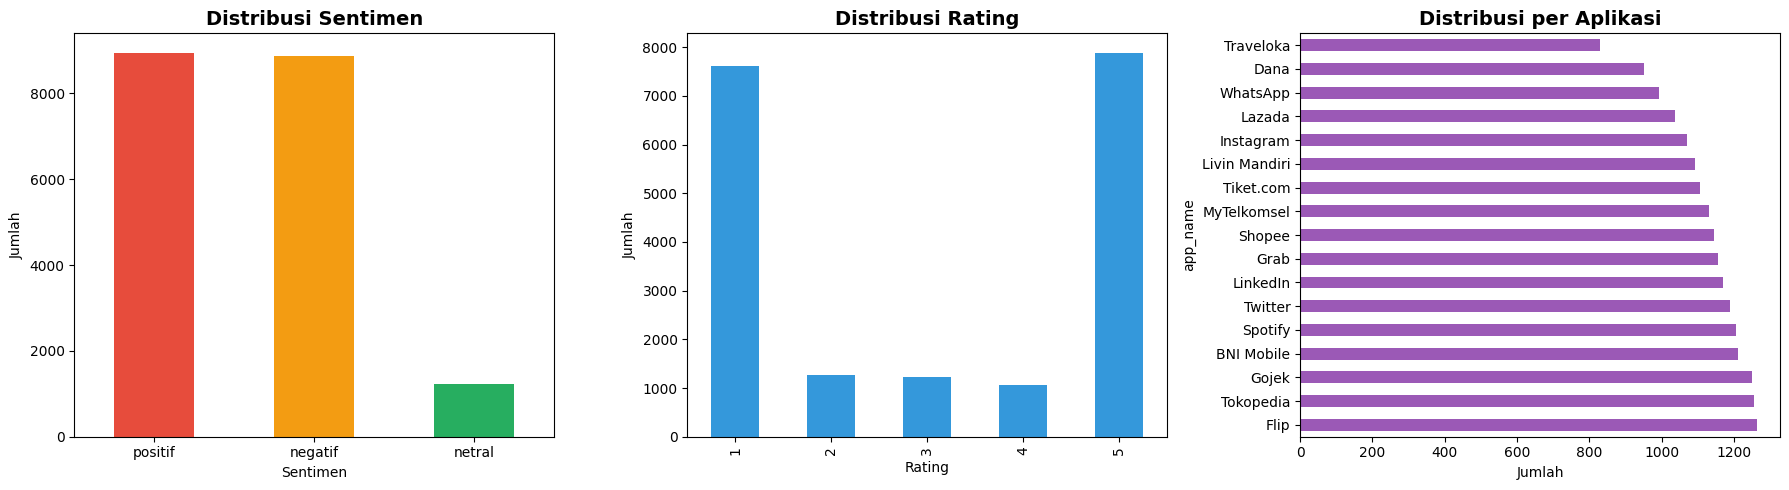

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#e74c3c', '#f39c12', '#27ae60']
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Sentimen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

df['score'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Distribusi Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah')

df['app_name'].value_counts().plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Distribusi per Aplikasi', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Data

In [7]:
tqdm.pandas()

# INIT
stopword_factory = StopWordRemoverFactory()
stopwords_id = set(stopword_factory.get_stop_words())

slang_dict = {
    'gk': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',
    'bgt': 'banget',
    'bgtt': 'banget',
    'jg': 'juga',
    'dr': 'dari',
    'krn': 'karena',
    'aja': 'saja'
}

negation_words = ['tidak', 'bukan', 'kurang']

def preprocess_text(text):
    if not isinstance(text, str): return ''

    text = text.lower()


    text = emoji.demojize(text)

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s:]', ' ', text)

    words = text.split()

    words = [slang_dict.get(w, w) for w in words]

    stop_words = set(stopword_factory.get_stop_words())
    keep_words = ['tidak', 'bukan', 'kurang', 'jangan', 'sangat', 'banget']

    words = [w for w in words if (w not in stop_words or w in keep_words)]

    return ' '.join(words)

print("Memulai preprocessing...")

if os.path.exists("clean_dataset.csv"):
    print("Load cached dataset...")
    df = pd.read_csv("clean_dataset.csv")
else:
    print("Processing dataset...")
    df['clean_text'] = df['content'].progress_apply(preprocess_text)
    df = df[df['clean_text'].str.strip().astype(bool)]
    df = df[df['clean_text'].str.split().str.len() >= 2]
    df.to_csv("clean_dataset.csv", index=False)


# hapus yang kosong
df = df[df['clean_text'].str.strip().astype(bool)]
df = df[df['clean_text'].str.split().str.len() >= 2]

df = df.reset_index(drop=True)

print(f"Data setelah preprocessing: {len(df)}")

Memulai preprocessing...
Processing dataset...


100%|██████████| 19056/19056 [00:05<00:00, 3357.81it/s]


Data setelah preprocessing: 18191


## 4. Encoding Label

In [8]:
# pisahkan kelas
df_neg = df[df.sentiment == 'negatif']
df_pos = df[df.sentiment == 'positif']
df_neu = df[df.sentiment == 'netral']

target_size = max(len(df_neg), len(df_neu), len(df_pos))

df_neg = resample(df_neg, replace=True, n_samples=target_size, random_state=42)
df_neu = resample(df_neu, replace=True, n_samples=target_size, random_state=42)
df_pos = resample(df_pos, replace=True, n_samples=target_size, random_state=42)

df = pd.concat([df_neg, df_neu, df_pos])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# label encoding
label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
label_map_reverse = {v: k for k, v in label_map.items()}

df['label_num'] = df['sentiment'].map(label_map)

# cek distribusi
print("Label Encoding:")
for k, v in label_map.items():
    count = len(df[df['sentiment'] == k])
    print(f"  {k} -> {v} ({count} samples)")

X = df['clean_text'].values
y = df['label_num'].values
print(f"\nTotal samples: {len(X)}")

Label Encoding:
  negatif -> 0 (8767 samples)
  netral -> 1 (8767 samples)
  positif -> 2 (8767 samples)

Total samples: 26301


---
## 5. Skema Pelatihan 1: Bidirectional LSTM (Deep Learning)
**Algoritma:** Bidirectional LSTM (PyTorch)

**Ekstraksi Fitur:** Word Embedding

**Pembagian Data:** 80/20

In [9]:
# Pembagian data 80/20
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {len(X_train_1)}")
print(f"Testing set: {len(X_test_1)}")

# Build vocabulary
word_counts = {}
for text in X_train_1:
    for w in text.split():
        word_counts[w] = word_counts.get(w, 0) + 1

MAX_WORDS = 15000
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:MAX_WORDS-2]
word2idx = {'<PAD>': 0, '<UNK>': 1}
for i, (w, _) in enumerate(sorted_words):
    word2idx[w] = i + 2

MAX_LEN = 128

def text_to_seq(text, word2idx, max_len):
    tokens = text.split()
    seq = [word2idx.get(w, 1) for w in tokens[:max_len]]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    return seq

X_train_seq = np.array([text_to_seq(t, word2idx, MAX_LEN) for t in X_train_1])
X_test_seq = np.array([text_to_seq(t, word2idx, MAX_LEN) for t in X_test_1])

print(f"Vocabulary size: {len(word2idx)}")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

Training set: 21040
Testing set: 5261
Vocabulary size: 12948
X_train_seq shape: (21040, 128)
X_test_seq shape: (5261, 128)


In [10]:
# PyTorch Dataset
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_dataset = SentimentDataset(X_train_seq, y_train_1)
test_dataset = SentimentDataset(X_test_seq, y_test_1)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# LSTM Model
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                           bidirectional=True, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        x = self.dropout(self.relu(self.fc1(hidden)))
        return self.fc2(x)

VOCAB_SIZE = len(word2idx)
EMBED_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 3
N_LAYERS = 2
DROPOUT = 0.3

model_lstm = BiLSTMSentiment(
    VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
).to(device)

if os.path.exists("lstm_full.pth"):
    checkpoint = torch.load("lstm_full.pth")
    model_lstm.load_state_dict(checkpoint['model_state'])
    word2idx = checkpoint['word2idx']
    MAX_LEN = checkpoint['max_len']
    print("Load checkpoint")
else:
    print("Train from scratch")

model_lstm.eval()

print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"\nTotal parameters: {total_params:,}")

Train from scratch
BiLSTMSentiment(
  (embedding): Embedding(12948, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)

Total parameters: 2,333,443


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

EPOCHS = 20
history = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}

best_acc = 0

for epoch in range(EPOCHS):
    # TRAIN
    model_lstm.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model_lstm(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_correct += (output.argmax(1) == y_batch).sum().item()
        train_total += X_batch.size(0)

    # EVALUATION
    model_lstm.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            output = model_lstm(X_batch)
            loss = criterion(output, y_batch)

            test_loss += loss.item() * X_batch.size(0)
            test_correct += (output.argmax(1) == y_batch).sum().item()
            test_total += X_batch.size(0)

    # METRICS
    t_acc = train_correct / train_total
    v_acc = test_correct / test_total
    t_loss = train_loss / train_total
    v_loss = test_loss / test_total

    history['train_acc'].append(t_acc)
    history['test_acc'].append(v_acc)
    history['train_loss'].append(t_loss)
    history['test_loss'].append(v_loss)

    scheduler.step(v_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {t_acc:.4f} Loss: {t_loss:.4f} | Test Acc: {v_acc:.4f} Loss: {v_loss:.4f}")

    #SAVE BEST MODEL
    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model_lstm.state_dict(), "best_lstm_model.pth")

    torch.save({
        'model_state': model_lstm.state_dict(),
        'word2idx': word2idx,
        'max_len': MAX_LEN
    }, "lstm_full.pth")

# LOAD BEST MODEL
model_lstm.load_state_dict(torch.load('best_lstm_model.pth'))
print(f"\nBest Test Accuracy: {best_acc:.4f}")

Epoch 1/20 | Train Acc: 0.5838 Loss: 0.8570 | Test Acc: 0.6942 Loss: 0.7021
Epoch 2/20 | Train Acc: 0.7351 Loss: 0.6477 | Test Acc: 0.7959 Loss: 0.5261
Epoch 3/20 | Train Acc: 0.8198 Loss: 0.4825 | Test Acc: 0.8232 Loss: 0.4809
Epoch 4/20 | Train Acc: 0.8686 Loss: 0.3626 | Test Acc: 0.8666 Loss: 0.3877
Epoch 5/20 | Train Acc: 0.8919 Loss: 0.2992 | Test Acc: 0.8879 Loss: 0.3418
Epoch 6/20 | Train Acc: 0.9123 Loss: 0.2499 | Test Acc: 0.9080 Loss: 0.2907
Epoch 7/20 | Train Acc: 0.9269 Loss: 0.2112 | Test Acc: 0.9175 Loss: 0.2759
Epoch 8/20 | Train Acc: 0.9356 Loss: 0.1867 | Test Acc: 0.9076 Loss: 0.3182
Epoch 9/20 | Train Acc: 0.9454 Loss: 0.1633 | Test Acc: 0.9105 Loss: 0.3212
Epoch 10/20 | Train Acc: 0.9497 Loss: 0.1447 | Test Acc: 0.9247 Loss: 0.2773
Epoch 11/20 | Train Acc: 0.9551 Loss: 0.1322 | Test Acc: 0.9224 Loss: 0.2977
Epoch 12/20 | Train Acc: 0.9677 Loss: 0.0953 | Test Acc: 0.9261 Loss: 0.3055
Epoch 13/20 | Train Acc: 0.9717 Loss: 0.0839 | Test Acc: 0.9255 Loss: 0.3237
Epoch 14

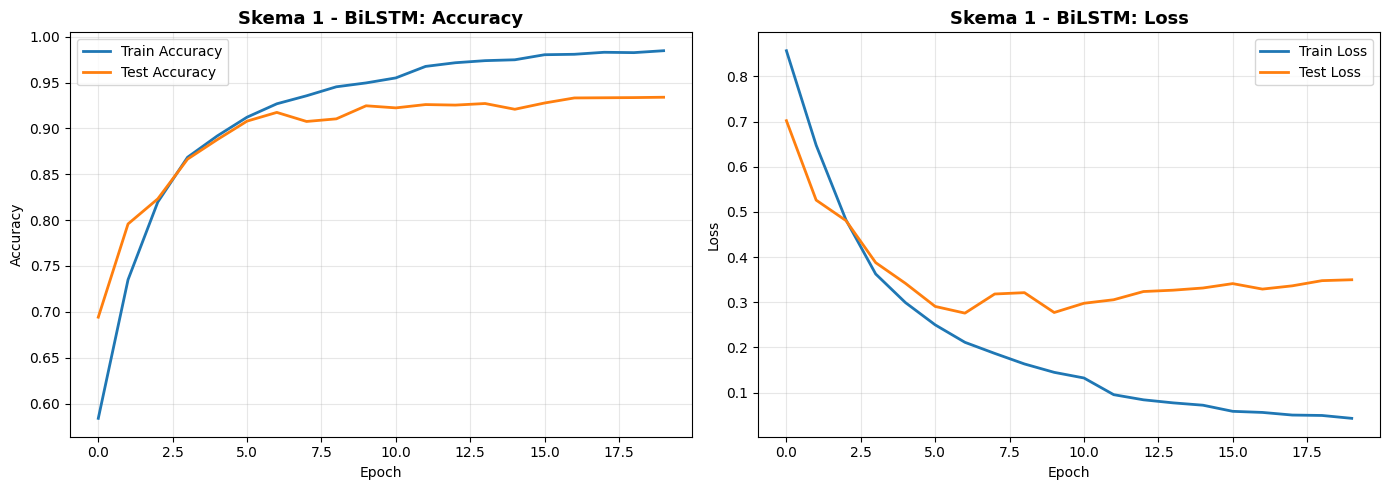

SKEMA 1 - Bidirectional LSTM (Deep Learning)
Training Accuracy : 99.77%
Testing Accuracy  : 93.40%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.94      0.90      0.92      1753
      netral       0.92      1.00      0.96      1754
     positif       0.94      0.91      0.93      1754

    accuracy                           0.93      5261
   macro avg       0.93      0.93      0.93      5261
weighted avg       0.93      0.93      0.93      5261



In [12]:
# Evaluasi LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['test_acc'], label='Test Accuracy', linewidth=2)
axes[0].set_title('Skema 1 - BiLSTM: Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[1].set_title('Skema 1 - BiLSTM: Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('skema1_lstm_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Final accuracies
model_lstm.eval()

train_preds = []
with torch.no_grad():
    for i in range(len(X_train_seq)):
        x = torch.LongTensor([X_train_seq[i]]).to(device)
        output = model_lstm(x)
        train_preds.append(output.argmax(1).item())

train_acc_lstm = accuracy_score(y_train_1, train_preds)

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model_lstm(X_batch)
        all_preds.extend(output.argmax(1).cpu().numpy())

test_acc_lstm = accuracy_score(y_test_1, all_preds)

print(f"{'='*50}")
print(f"SKEMA 1 - Bidirectional LSTM (Deep Learning)")
print(f"{'='*50}")
print(f"Training Accuracy : {train_acc_lstm*100:.2f}%")
print(f"Testing Accuracy  : {test_acc_lstm*100:.2f}%")
print(f"{'='*50}")
print(f"\nClassification Report:")
print(classification_report(y_test_1, all_preds, target_names=['negatif','netral','positif']))

---
## 6. Skema Pelatihan 2: SVM + TF-IDF
**Algoritma:** Support Vector Machine (SVM)

**Ekstraksi Fitur:** TF-IDF

**Pembagian Data:** 80/20

TF-IDF shape: (21040, 20000)
Training SVM...

SKEMA 2 - SVM + TF-IDF (OPTIMIZED)
Training Accuracy : 99.12%
Testing Accuracy  : 93.40%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.92      0.92      0.92      1753
      netral       0.95      0.99      0.97      1754
     positif       0.93      0.90      0.92      1754

    accuracy                           0.93      5261
   macro avg       0.93      0.93      0.93      5261
weighted avg       0.93      0.93      0.93      5261



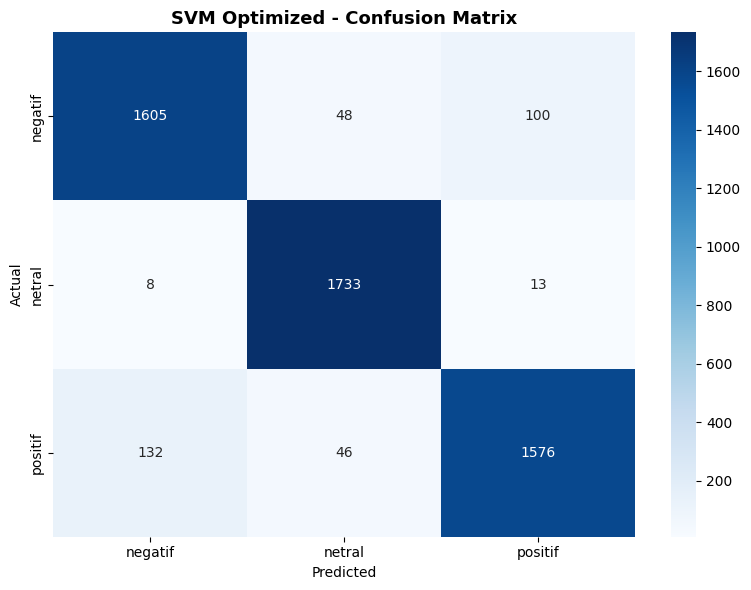

In [13]:
# =========================
# TF-IDF (OPTIMIZED)
# =========================
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# =========================
# SPLIT
# =========================
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# VECTORIZE
# =========================
X_train_tfidf = tfidf.fit_transform(X_train_2)
X_test_tfidf = tfidf.transform(X_test_2)

X_train_tfidf = X_train_tfidf.astype('float32')
X_test_tfidf = X_test_tfidf.astype('float32')

print(f"TF-IDF shape: {X_train_tfidf.shape}")

# =========================
# SVM (OPTIMIZED)
# =========================
svm_model = LinearSVC(
    C=2.0,
    class_weight='balanced',
    max_iter=30000,
    tol=1e-4
)

print("Training SVM...")
svm_model.fit(X_train_tfidf, y_train_2)

# =========================
# EVALUATION
# =========================
y_pred_train = svm_model.predict(X_train_tfidf)
y_pred_test = svm_model.predict(X_test_tfidf)

train_acc_svm = accuracy_score(y_train_2, y_pred_train)
test_acc_svm = accuracy_score(y_test_2, y_pred_test)

print(f"\n{'='*50}")
print("SKEMA 2 - SVM + TF-IDF (OPTIMIZED)")
print(f"{'='*50}")
print(f"Training Accuracy : {train_acc_svm*100:.2f}%")
print(f"Testing Accuracy  : {test_acc_svm*100:.2f}%")
print(f"{'='*50}")

# =========================
# REPORT
# =========================
print("\nClassification Report:")
print(classification_report(
    y_test_2,
    y_pred_test,
    target_names=['negatif','netral','positif']
))

# =========================
# CONFUSION MATRIX
# =========================
cm_svm = confusion_matrix(y_test_2, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negatif','netral','positif'],
    yticklabels=['negatif','netral','positif']
)

plt.title('SVM Optimized - Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('svm_optimized_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Error analysis
wrong = X_test_2[y_test_2 != y_pred_test]

print("Contoh kesalahan prediksi:")
for i in range(5):
    print(wrong[i])

Contoh kesalahan prediksi:
wa tidak fitur meng hd kan status naruk sw sya hd iri temen hd kan story wa nya
apk dompet monyet gak trasaksi perbulan diatas 20juta blm muncul dana cicilnya
coba dulu
bagus lambat konfirmasi pembayarannya
sengaja ngasih bintang 5 soalnya aplikasi gajelas mau login selalu keluar sendiri loading nya lama


In [17]:
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

joblib.dump({
    "model": svm_model,
    "tfidf": tfidf
}, "svm_full.pkl")

['svm_full.pkl']

In [22]:
vectorizer_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,6),
    max_features=50000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char = vectorizer_char.fit_transform(X_train_2)
X_test_char = vectorizer_char.transform(X_test_2)

print("Shape:", X_train_char.shape)

vectorizer_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,7),
    max_features=70000,
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char = vectorizer_char.fit_transform(X_train_2)
X_test_char = vectorizer_char.transform(X_test_2)

print("Shape:", X_train_char.shape)

Shape: (21040, 50000)
Shape: (21040, 70000)


In [23]:
model_char = LogisticRegression(
    max_iter=6000,
    C=4.0,
    class_weight='balanced',
    solver='saga',
    n_jobs=-1
)

model_char.fit(X_train_char, y_train_2)

y_pred_char = model_char.predict(X_test_char)
char_acc = accuracy_score(y_test_2, y_pred_char)

print("Char N-gram Accuracy:", char_acc)

Char N-gram Accuracy: 0.9245390610150162


---
## 7. Skema Pelatihan 3: IndoBERT (Transformer)
**Algoritma:** IndoBERT

In [24]:
LOAD_ONLY = False

# =========================
# DATASET
# =========================
df['label_num'] = df['sentiment'].map(label_map)

dataset = HFDataset.from_pandas(df[['clean_text','label_num']])
dataset = dataset.rename_column("label_num", "labels")
dataset = dataset.train_test_split(test_size=0.2, seed=42)


# =========================
# TOKENIZER
# =========================
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize(batch):
    return tokenizer(
        batch['clean_text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type='torch', columns=['input_ids','attention_mask','labels'])

# =========================
# MODEL (RESUME SUPPORT)
# =========================
if os.path.exists("indobert_model"):
    print("Load model lokal...")
    model = AutoModelForSequenceClassification.from_pretrained("./indobert_model")
else:
    print("Load base model...")
    model = AutoModelForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p1",
        num_labels=3,
        use_safetensors=True,
        ignore_mismatched_sizes=True

    )

# =========================
# METRIC
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

# =========================
# TRAIN CONFIG (TARGET 92%)
# =========================
training_args = TrainingArguments(
    output_dir="./bert_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    report_to="none",
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

torch.set_num_threads(4)

# =========================
# TRAIN / LOAD
# =========================
if not LOAD_ONLY:
    trainer.train()
    trainer.save_model("indobert_model")
    tokenizer.save_pretrained("indobert_model")

# =========================
# EVALUATION
# =========================
predictions = trainer.predict(dataset['test'])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

indobert_acc = accuracy_score(y_true, y_pred)

print("IndoBERT Accuracy:", indobert_acc)
print(classification_report(y_true, y_pred, target_names=['negatif','netral','positif']))

Map:   0%|          | 0/21040 [00:00<?, ? examples/s]

Map:   0%|          | 0/5261 [00:00<?, ? examples/s]

Load base model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
100,1.047089
200,0.794264
300,0.710762
400,0.727022
500,0.695415
600,0.692795
700,0.630892
800,0.563226
900,0.601535
1000,0.506224


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

IndoBERT Accuracy: 0.9456377114616993
              precision    recall  f1-score   support

     negatif       0.94      0.92      0.93      1727
      netral       0.95      0.99      0.97      1746
     positif       0.95      0.93      0.94      1788

    accuracy                           0.95      5261
   macro avg       0.95      0.95      0.95      5261
weighted avg       0.95      0.95      0.95      5261



In [25]:
trainer.save_model("indobert_model")
tokenizer.save_pretrained("indobert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('indobert_model/tokenizer_config.json', 'indobert_model/tokenizer.json')

---
## 8. Ringkasan Hasil Pelatihan

In [27]:
print("=" * 70)
print("RINGKASAN HASIL MODEL")
print("=" * 70)

# ================= LSTM =================
try:
    checkpoint = torch.load("lstm_full.pth")

    model_lstm = BiLSTMSentiment(
        VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
    ).to(device)

    model_lstm.load_state_dict(checkpoint['model_state'])
    model_lstm.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model_lstm(X_batch)
            preds = output.argmax(1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    lstm_acc = correct / total
    lstm_status = f"READY ({lstm_acc*100:.2f}%)"

except:
    lstm_status = "NOT FOUND"


# ================= SVM =================
try:
    svm_bundle = joblib.load("svm_full.pkl")
    svm_model = svm_bundle["model"]
    tfidf = svm_bundle["tfidf"]

    X_test_vec = tfidf.transform(X_test_2)
    y_pred = svm_model.predict(X_test_vec)

    svm_acc = accuracy_score(y_test_2, y_pred)
    svm_status = f"READY ({svm_acc*100:.2f}%)"

except:
    svm_status = "NOT FOUND"


# ================= BERT =================
try:
    bert_model = AutoModelForSequenceClassification.from_pretrained("./indobert_model")
    bert_model.eval()

    preds = trainer.predict(dataset['test'])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    bert_acc = accuracy_score(y_true, y_pred)
    bert_status = f"READY ({bert_acc*100:.2f}%)"

except:
    bert_status = "NOT FOUND"


# ================= PRINT =================
print(f"LSTM      : {lstm_status}")
print(f"SVM       : {svm_status}")
print(f"IndoBERT  : {bert_status}")
print("=" * 70)

RINGKASAN HASIL MODEL


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

LSTM      : READY (93.40%)
SVM       : READY (93.40%)
IndoBERT  : READY (94.56%)


---
## 9. Inference / Testing
Melakukan prediksi sentimen pada teks baru menggunakan beberapa model (LSTM dan SVM)

In [28]:
# =========================
# LOAD INDOBERT
# =========================
indobert_model = AutoModelForSequenceClassification.from_pretrained("./indobert_model")
indobert_tokenizer = AutoTokenizer.from_pretrained("./indobert_model")

indobert_model.eval()

# =========================
# PREDICT LSTM
# =========================
def predict_sentiment(text):
    clean = preprocess_text(text)
    seq = text_to_seq(clean, word2idx, MAX_LEN)
    tensor = torch.LongTensor([seq]).to(device)

    model_lstm.eval()
    with torch.no_grad():
        output = model_lstm(tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = output.argmax(1).item()
        confidence = probs[0][pred_class].item() * 100

    return label_map_reverse[pred_class], confidence


# =========================
# PREDICT SVM
# =========================
def predict_svm(text):
    text = preprocess_text(text)
    vec = tfidf.transform([text])
    pred = svm_model.predict(vec)[0]
    return label_map_reverse[pred]


# =========================
# PREDICT INDOBERT
# =========================
def predict_indobert(text):
    inputs = indobert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = indobert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    return label_map_reverse[pred_class]


# =========================
# TEST DATA
# =========================
test_texts = [
    "Aplikasi ini sangat bagus dan membantu sekali, recommended!",
    "Buruk sekali, sering crash dan lemot, tidak bisa dipakai",
    "Aplikasinya biasa saja, ada kelebihan dan kekurangannya",
    "Update terbaru membuat aplikasi makin smooth dan cepat",
    "Mengecewakan, fitur pembayaran error terus, sudah lapor tapi tidak diperbaiki",
    "Lumayan lah, kadang bagus kadang error",
    "Sangat membantu untuk kehidupan sehari-hari, mantap!",
    "Tolong perbaiki bug-nya, sudah tidak bisa login sejak kemarin",
    "Biasa aja sih, nothing special",
    "Luar biasa! Best app ever, sangat puas menggunakannya"
]


# =========================
# INFERENCE
# =========================
print("=" * 70)
print("HASIL INFERENCE / PREDIKSI SENTIMEN")
print("=" * 70)

for i, text in enumerate(test_texts, 1):
    lstm_sent, confidence = predict_sentiment(text)
    svm_sent = predict_svm(text)
    indo_sent = predict_indobert(text)

    print(f"\n[{i}] Teks      : {text}")
    print(f"    LSTM       : {lstm_sent.upper()} ({confidence:.2f}%)")
    print(f"    SVM        : {svm_sent.upper()}")
    print(f"    IndoBERT   : {indo_sent.upper()}")
    print("-" * 70)

print("\n" + "=" * 70)
print("INFERENCE SELESAI - Semua model berhasil digunakan")
print("=" * 70)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

HASIL INFERENCE / PREDIKSI SENTIMEN

[1] Teks      : Aplikasi ini sangat bagus dan membantu sekali, recommended!
    LSTM       : POSITIF (100.00%)
    SVM        : POSITIF
    IndoBERT   : POSITIF
----------------------------------------------------------------------

[2] Teks      : Buruk sekali, sering crash dan lemot, tidak bisa dipakai
    LSTM       : NEGATIF (99.95%)
    SVM        : NEGATIF
    IndoBERT   : NEGATIF
----------------------------------------------------------------------

[3] Teks      : Aplikasinya biasa saja, ada kelebihan dan kekurangannya
    LSTM       : POSITIF (99.96%)
    SVM        : POSITIF
    IndoBERT   : POSITIF
----------------------------------------------------------------------

[4] Teks      : Update terbaru membuat aplikasi makin smooth dan cepat
    LSTM       : NEGATIF (94.54%)
    SVM        : NEGATIF
    IndoBERT   : POSITIF
----------------------------------------------------------------------

[5] Teks      : Mengecewakan, fitur pembayaran